# GEDF impact on CMB power spectra vs `rho_gedf`

This notebook runs the modified CLASS executable (`./class`) for a grid of `rho_gedf` values and compares lensed CMB spectra (`TT`, `EE`, `TE`) against `rho_gedf=0`.

Settings:
- `ac_gedf = 1/3400`
- `s_a_gedf = 10000`
- Planck-like baseline cosmology (same values used in this repository)

In [8]:
import os
os.environ.setdefault('KMP_USE_SHM', '0')

import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 130

# Resolve CLASS binary whether notebook is started from repo root or notebooks/.
def find_class_bin() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd / 'class', cwd.parent / 'class']
    for c in candidates:
        if c.exists() and c.is_file():
            return c
    p = cwd
    for _ in range(5):
        c = p / 'class'
        if c.exists() and c.is_file():
            return c
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Could not find CLASS binary named 'class' from cwd={cwd}. "
        "Start Jupyter in the CLASS repo, or set CLASS_BIN manually."
    )

CLASS_BIN = find_class_bin()
REPO_ROOT = CLASS_BIN.parent
print(f'Using CLASS binary: {CLASS_BIN}')

outdir = REPO_ROOT / 'output' / 'gedf_rho_study'
outdir.mkdir(parents=True, exist_ok=True)

rho_values = [0, 100, 400, 1600, 6400, 25600]
L_MAX_SCALARS = 3500

base_ini = """
output = tCl,pCl,lCl
lensing = yes
l_max_scalars = {L_MAX_SCALARS}
h = 0.67810
omega_b = 0.02238280
omega_cdm = 0.1201075
A_s = 2.100549e-09
n_s = 0.9660499
tau_reio = 0.05430842
N_ur = 3.044
YHe = BBN
recombination = HyRec
ac_gedf = 0.0002941176470588235
s_a_gedf = 10000.
overwrite_root = yes
""".strip().format(L_MAX_SCALARS=L_MAX_SCALARS)

def run_model(rho):
    stem = f'gedf_rho{rho}'
    ini = outdir / f'{stem}.ini'

    # CLASS expects a root relative to run directory.
    root_rel = f'output/gedf_rho_study/{stem}'
    ini.write_text(base_ini + f"\nrho_gedf = {float(rho)}\nroot = {root_rel}\n")

    proc = subprocess.run(
        [str(CLASS_BIN), str(ini)],
        capture_output=True,
        text=True,
        cwd=REPO_ROOT,
    )
    if proc.returncode != 0:
        raise RuntimeError(f'CLASS failed for rho_gedf={rho}\n{proc.stdout}\n{proc.stderr}')

    cl_file = REPO_ROOT / f'{root_rel}00_cl_lensed.dat'
    arr = np.loadtxt(cl_file)

    # Sanity check: ensure CLASS respected requested l_max_scalars.
    if int(arr[-1, 0]) != L_MAX_SCALARS:
        raise RuntimeError(
            f"Expected ell max {L_MAX_SCALARS}, got {int(arr[-1,0])}. "
            "Delete old outputs or check CLASS run options."
        )
    return {
        'ell': arr[:, 0].astype(int),
        'TT': arr[:, 1],
        'EE': arr[:, 2],
        'TE': arr[:, 3],
    }

Using CLASS binary: /home/lutein/Projects/class_public-3.3.3-gedf/class


In [ ]:
results = {rho: run_model(rho) for rho in rho_values}
ref = results[0]
ell = ref['ell']

header = 'rho_gedf  dTT(ell=200)%  dTT(ell=1000)%  dTT(ell=2000)%'
print(header)
for rho in rho_values:
    r = results[rho]
    vals = []
    for l in [200, 1000, 2000]:
        i = np.where(ell == l)[0][0]
        vals.append((r['TT'][i] / ref['TT'][i] - 1.0) * 100.0)
    print(f'{rho:7d}  {vals[0]:12.6e}  {vals[1]:13.6e}  {vals[2]:13.6e}')

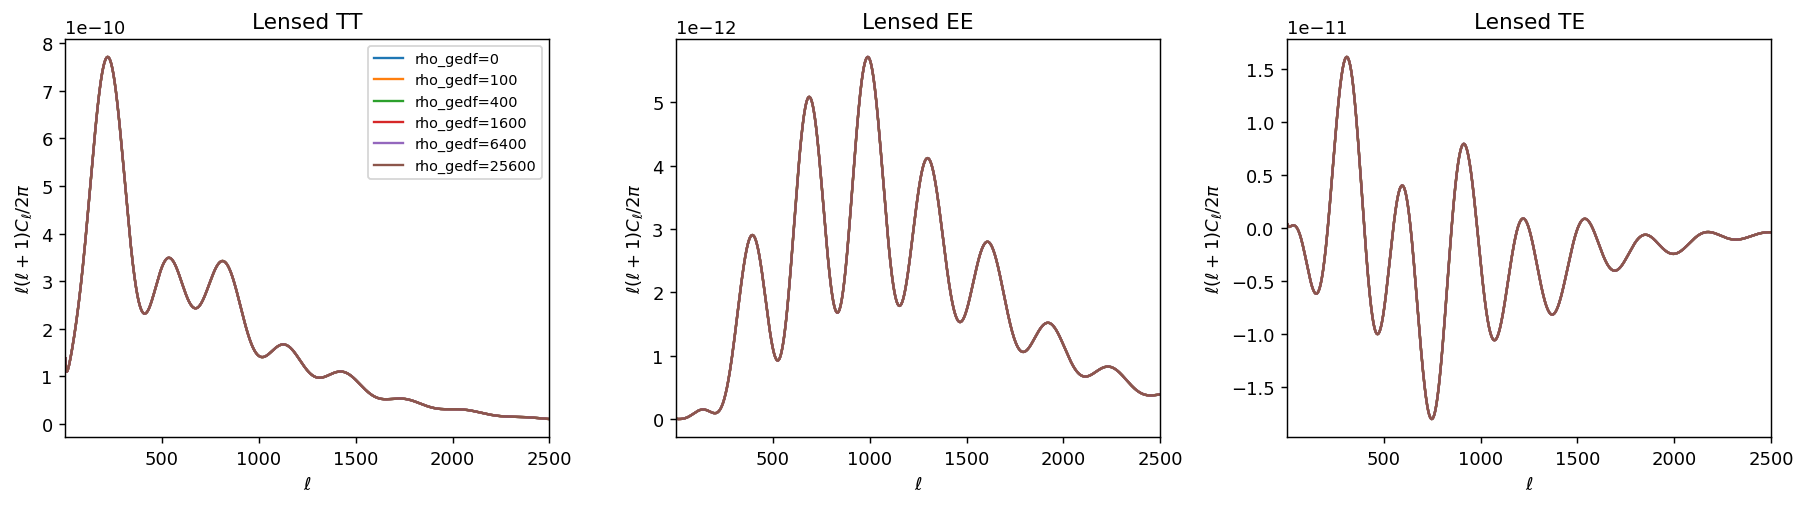

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for rho in rho_values:
    lab = f'rho_gedf={rho}'
    axes[0].plot(ell, results[rho]['TT'], label=lab, lw=1.3)
    axes[1].plot(ell, results[rho]['EE'], label=lab, lw=1.3)
    axes[2].plot(ell, results[rho]['TE'], label=lab, lw=1.3)

axes[0].set_title('Lensed TT')
axes[1].set_title('Lensed EE')
axes[2].set_title('Lensed TE')
for ax in axes:
    ax.set_xlim(2, L_MAX_SCALARS)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

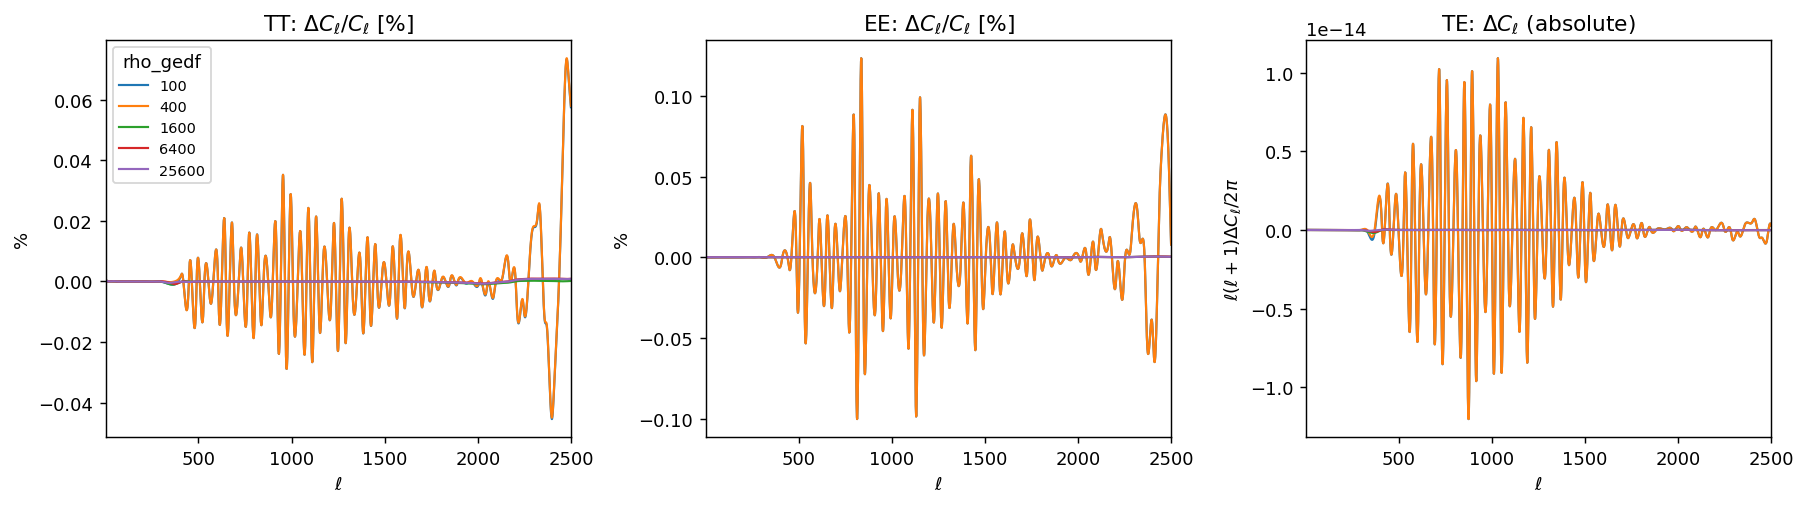

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for rho in rho_values[1:]:
    dtt = (results[rho]['TT']/ref['TT'] - 1.0) * 100.0
    dee = (results[rho]['EE']/ref['EE'] - 1.0) * 100.0

    # TE crosses zero, so show absolute delta.
    dte_abs = results[rho]['TE'] - ref['TE']

    axes[0].plot(ell, dtt, label=f'{rho}', lw=1.2)
    axes[1].plot(ell, dee, label=f'{rho}', lw=1.2)
    axes[2].plot(ell, dte_abs, label=f'{rho}', lw=1.2)

axes[0].set_title(r'TT: $\Delta C_\ell/C_\ell$ [%]')
axes[1].set_title(r'EE: $\Delta C_\ell/C_\ell$ [%]')
axes[2].set_title(r'TE: $\Delta C_\ell$ (absolute)')
for ax in axes:
    ax.set_xlim(2, L_MAX_SCALARS)
    ax.set_xlabel(r'$\ell$')
axes[0].set_ylabel('%')
axes[1].set_ylabel('%')
axes[2].set_ylabel(r'$\ell(\ell+1)\Delta C_\ell/2\pi$')
axes[0].legend(title='rho_gedf', fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
print('rho_gedf, max|dTT|[%], ell(dTT), max|dEE|[%], ell(dEE), max|dTE|[abs], ell(dTE)')
for rho in rho_values[1:]:
    dtt = np.abs((results[rho]['TT']/ref['TT'] - 1.0) * 100.0)
    dee = np.abs((results[rho]['EE']/ref['EE'] - 1.0) * 100.0)
    dte = np.abs(results[rho]['TE'] - ref['TE'])
    print(f"{rho}, {dtt.max():.6e}, {ell[np.argmax(dtt)]}, {dee.max():.6e}, {ell[np.argmax(dee)]}, {dte.max():.6e}, {ell[np.argmax(dte)]}")

rho_gedf, max|dTT|[%], ell(dTT), max|dEE|[%], ell(dEE), max|dTE|[abs], ell(dTE)
100, 7.344912e-02, 2477, 1.233321e-01, 836, 1.204008e-14, 875
400, 7.379721e-02, 2477, 1.232985e-01, 836, 1.203593e-14, 875
1600, 1.037595e-03, 361, 4.414225e-04, 2403, 1.890867e-16, 364
6400, 9.689463e-04, 2395, 4.816206e-04, 2413, 1.310167e-16, 369
25600, 9.001223e-04, 2416, 4.301080e-04, 2408, 5.529065e-17, 341
